# Logistic Regression in Python

---

## 1. Introduction

This notebook demonstrates how to fit logistic regression models for **binary** outcome variables—variables that can take only two distinct values. As an example, we will use the variable `smoked`, which we will derive from the `SMQ020` variable in the NHANES dataset.

The `smoked` variable indicates whether a person has smoked at least 100 cigarettes in their lifetime (a common definition of having a "smoking history"). We will recode this variable so that individuals with a smoking history are coded as 1 (smoker) and those without as 0 (non-smoker). Rare or ambiguous responses (such as *don't know* or *refused to answer*) will be treated as missing values.

In our analysis, we will explore how plausible predictors—such as age, gender, and educational attainment—are associated with smoking history using logistic regression models.

---

## 2. Import Libraries, Load and Prepare the Data
First, we import the standard libraries for data manipulation, visualization, and statistical modeling (e.g., pandas, numpy, matplotlib/seaborn, and statsmodels). 

Then we load the NHANES 2015–2016 data. NHANES includes multiple waves; this notebook uses only the 2015–2016 wave.

As with most datasets, NHANES contains missing values. For simplicity we perform a **complete‑case analysis**: we  drop observations with missing values in any of the key variables used in this notebook. 

> **Note:** Complete‑case analysis reduces the effective sample size and can bias estimates and standard errors unless the missingness mechanism is missing completely at random (MCAR). In practice you should consider alternatives such as single or multiple imputation, or other methods that explicitly model missingness.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Read the 2015-2016 wave of NHANES data
nhanes_df = pd.read_csv("./data/nhanes_2015_2016.csv")

# Select columns of interest and drop observations with missing values
nhanes_df["smoked"] = nhanes_df["SMQ020"].replace({2: 0, 7: np.nan, 9: np.nan})
cols = ["DMDEDUC2", "RIAGENDR", "RIDAGEYR", "smoked"]
nhanes_df = nhanes_df[cols].dropna().reset_index(drop=True)

# Rename columns
nhanes_df = nhanes_df.rename(columns={"RIDAGEYR" : "age", "RIAGENDR": "gender", "DMDEDUC2": "education"})

# Add a `gender_labeled` column
nhanes_df["gender_labeled"] = nhanes_df["gender"].replace({1: "Male", 2:"Female"})

# Print the first 5 rows
nhanes_df.head()

,education,gender,age,smoked,gender_labeled
0,5.0,1,62,1.0,Male
1,3.0,1,53,1.0,Male
2,3.0,1,78,1.0,Male
3,5.0,2,56,0.0,Female
4,4.0,2,42,0.0,Female



---

## 3. Odds and Log Odds

Logistic regression models the **odds** of an event occurring, rather than modeling the probability directly. Recall that if an event has probability $p$, the odds of the event are defined as $p / (1 - p)$. In other words, the odds represent the ratio of the probability that the event occurs to the probability that it does not occur. For example, if the probability is $1/2$, then the odds are $1$.

This transformation allows us to work on a different scale, which has mathematical advantages in regression modeling.

To illustrate, let’s start by examining the odds of smoking separately for women and men.

In [31]:
# Create a contingency table (counts) of gender vs. smoking status
counts = pd.crosstab(nhanes_df["gender_labeled"], nhanes_df["smoked"])

# Convert the counts to proportions within each gender (row-wise proportions)
proportions = counts.div(counts.sum(axis=1), axis=0)

# Calculate the odds of smoking for each gender
proportions["odds"] = proportions[1] / proportions[0]

# Display the table with proportions and odds
proportions

smoked,0.0,1.0,odds
gender_labeled,,,
Female,0.684821,0.315179,0.460236
Male,0.467914,0.532086,1.137143


We see that the probability that a woman has ever smoked is substantially lower than the probability that a man has ever smoked (32% vs 53%). This is reflected in the odds for a woman smoking being much less than 1 (around 0.47), while the odds for a man smoking is around 1.14.

It is common to work with **odds ratios** when comparing two groups. This is simply the odds for one group divided by the odds for the other group. The odds ratio for smoking, comparing males to females, is around 2.4. In other words, a man has around 2.47 times greater odds of smoking than a woman (in the population represented by these data).

In [32]:
print(proportions["odds"]["Male"] / proportions["odds"]["Female"])

2.470781971651537


### Why Do We Use Log Odds?
We've mentioned that modeling odds instead of probability has mathematical advantages in regression modeling. However using the odds as they are has also its issues. Therefore it is common to work with odds on the logarithmic scale, known as **log odds**. Here's why:

* The "neutral" probability is 0.5 (50%), which corresponds to odds of 1 and log odds of 0.
* If men are more likely to smoke than women, the odds for men compared to women will be greater than 1 (from 1 up to infinity). If women are more likely to smoke, the odds will be between 0 and 1.
* The **odds scale is not symmetric:** it ranges from 0 to 1 in one direction, and 1 to infinity in the other. For example, an odds of 2 (men twice as likely as women) is just as "strong" as an odds of 0.5 (women twice as likely as men), but the numbers look very different.

By taking the logarithm of the odds, we:

* Center the scale at zero (log odds of 0 means equal odds).
* Make the scale symmetric: a log odds of +2 (men) is just as strong as -2 (women), only the direction changes.

#### How to interpret log odds:
* Probability = 0.5, odds = 1, log odds = 0 all mean "no difference between groups."
* Positive log odds: the first group is more likely.
* Negative log odds: the second group is more likely.
* The farther from zero (positive or negative), the stronger the association.

To convert log odds back to odds, use the exponential function. For example, a log odds of 2 means odds = exp(2) ≈ 7.4.

> **Note:** While you can convert log odds to odds, you cannot directly recover the underlying probabilities for each group from the odds ratio alone.

Below we show the log odds for smoking history status of females and males in the NHANES data.  

In [33]:
proportions["logodds"] = np.log(proportions["odds"])
proportions

smoked,0.0,1.0,odds,logodds
gender_labeled,,,,
Female,0.684821,0.315179,0.460236,-0.776016
Male,0.467914,0.532086,1.137143,0.128519


This table tells us that:
* For females, the log odds for having smoked is negative, meaning fewer than half have smoked.
* For males, the log odds is closer to zero, meaning about half have smoked.

---

## 4. Fitting a Simple Logistic Regression Model
Now it's time to fit a simple logistic regression model, a model with only one covariate, to our data. Let's start with `gender` as our only predictor. 

We fit the model using the `GLM` function, which stands for **Generalized Linear Model**. Logistic regression is one type of GLM, but there are many other GLMs such as Poisson regression that we don't discuss further here. 

As with linear regression, logistic models also include an intercept parameter, but we are not focusing on that parameter now.

In [34]:
model = sm.GLM.from_formula("smoked ~ gender_labeled", family=sm.families.Binomial(), data=nhanes_df)
result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 smoked   No. Observations:                 5464
Model:                            GLM   Df Residuals:                     5462
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3582.8
Date:                Thu, 23 Oct 2025   Deviance:                       7165.7
Time:                        12:54:14   Pearson chi2:                 5.46e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04741
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

Note that the logistic regression coefficient for male gender is exactly equal to the difference between the log odds statistics for males and females:

In [37]:
print(proportions["logodds"]["Male"] - proportions["logodds"]["Female"])

0.9045346882497431


This relationship will always hold for simple logistic regression.

In general, a logistic regression model will have multiple covariates that may not be binary, but there is still an important connection between logistic regression and odds ratio. In this more general setting, we will use a more general type of odds ration, which we will explore further next.

---

## 5. Fitting a Multiple Logistic Regression Model
Let's add `age` as a second predictor to our model.

In [38]:
model = sm.GLM.from_formula("smoked ~ gender_labeled + age", family=sm.families.Binomial(), data=nhanes_df)
result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 smoked   No. Observations:                 5464
Model:                            GLM   Df Residuals:                     5461
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3523.4
Date:                Thu, 23 Oct 2025   Deviance:                       7046.8
Time:                        12:59:05   Pearson chi2:                 5.47e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06792
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1

### Interpreting Regression Parameters

* Adding age to the model leads to a very small shift in the gender parameter. In general, regression coefficients can change a lot when adding or removing other variables from a model. The reason we had a very small change is that our predictors of age and gender are not correlated.
* The fitted model suggests that older people are more likely to have a history of smoking than younger people. The **log odds** for smoking increases by 0.0175 by age. This effect is additive, so that comparing two people whose ages differ by 20 years, the *log odds* of the older person smoking will be around 0.35 units greater than the *log odds* for the younger person smoking, and the *odds* for the older person smoking will be around `exp(0.35) = 1.4` times greater than the *odds* for the younger person smoking.
* However, it's important to note that the definition of smoking status in the study might affect this result, since an older person has more time to smoke 100 cigarettes than a younger person. That being said, if we add the information that the smoking rate in the US has been slowly declining for several decades, we can assume that the increased smoking levels in older people are driven primarily by real shifts in behavior.
* As with linear regression, the roles of age and gender in the logistic regression model can be seen as being additive, but here the additivity is on the scale of log odds, not odds or probabilities.
* Again, as with linear regression, the coefficients for age and gender both have interpretations in terms of *conditional log odds*. When there are two or more covariates in a logistic regression model, we always need to think in terms of conditional, not marginal log odds.

---

## 6. Multiple Logistic Regression Model with Three Variables
Next we fit a logistic regression model, again for smoking, including educational attainment as the third predictor. First, we'll have to recode the `education` variable so that the meaning of the levels becomes more clear.

In [ ]:
# Create a labeled version of the educational attainment variable
nhanes_df["education_labeled"] = nhanes_df["education"].replace({
    1: "lt9",
    2: "xp_11",
    3: "HS",
    4: "SomeCollege",
    5: "College",
    7: np.nan, 
    9: np.nan
})

model = sm.GLM.from_formula("smoked ~ age + gender_labeled + education_labeled", family=sm.families.Binomial(), data=nhanes_df)
result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 smoked   No. Observations:                 5463
Model:                            GLM   Df Residuals:                     5456
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3421.3
Date:                Thu, 23 Oct 2025   Deviance:                       6842.6
Time:                        13:26:37   Pearson chi2:                 5.47e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1019
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

### Interpreting Regression Parameters
* All non-reference coefficients for the educational attainment are positive, while the College coefficient, as the reference coefficient, is exactly zero. Thus, we see that people with a college degree have the lowest rate of smoking, followed by people with less than 9 years of schooling, then (after a large gap) people with some college, then people with a high school degree (and no college), and finally (with the greatest rate of smoking), people with 9-11 years of schooling. 
* The overall story here is that smoking rates are much lower for people who graduated from college or did not start high school, presumably for very different reasons. 
* On the other hand, people with some high school, people who completed high school, and people who began but did not complete college have much higher rates of smoking.

---

## 7. Visualization of Logistic Regression Models
Visualization of fitted logistic regression models is more challenging than visualization of fitted linear models, but is still worth pursuing.

We can begin by plotting the fitted proportion of the population that smokes, for various subpopulations defined by the regression model. We will focus here on how the smoking rate varies with age, so we restrict the population to female college graduates.

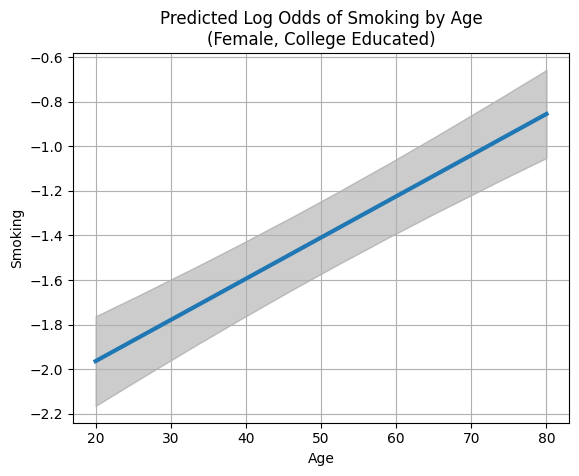

In [47]:
from statsmodels.sandbox.predict_functional import predict_functional

# We have to fix all non-focus parameters even if we won't plot them to avoid errors
values = {"gender_labeled": "Female", "gender": 1, "education": 1, "smoked": 1, "education_labeled": "College"}

preds, confidence_bands, function_values = predict_functional(result, "age", values=values, ci_method="simultaneous")

ax = sns.lineplot(x=function_values, y=preds, lw=3)
ax.fill_between(function_values, confidence_bands[:, 0], confidence_bands[:, 1], color='grey', alpha=0.4)
ax.set_title("Predicted Log Odds of Smoking by Age\n(Female, College Educated)")
ax.set_xlabel("Age")
ax.set_ylabel("Smoking")
ax.grid(True)
plt.show()

We can display the same plot in terms of probabilities instead of in terms of log odds. The probability can be obtained from the log odds using the relationship $p = 1 / (1 + \exp(-o))$ where $o$ is the log
odds.

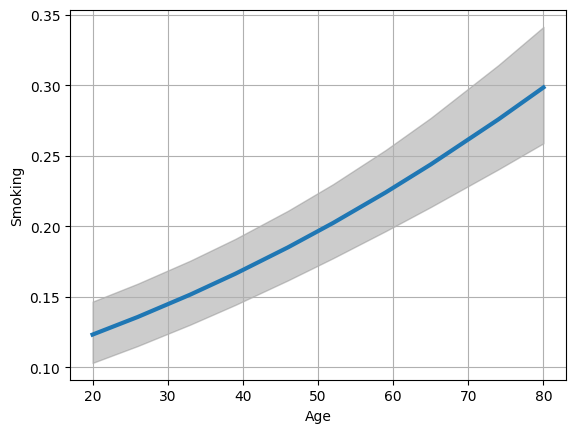

In [48]:
preds_prob = 1 / (1 + np.exp(-preds))
confidence_bands_prob = 1 / (1 + np.exp(-confidence_bands))
ax.set_title("Predicted Probability of Smoking by Age\n(Female, College Educated)")
ax = sns.lineplot(x=function_values, y=preds_prob, lw=3)
ax.fill_between(function_values, confidence_bands_prob[:, 0], confidence_bands_prob[:, 1], color='grey', alpha=0.4)

ax.set_xlabel("Age")
ax.set_ylabel("Smoking")
ax.grid(True)
plt.show()

> **Note:** While the age and log odds are linearly related, age has a curved relationship with probability.  This is necessary since probabilities must remain between 0 and 1, a linear relationship would eventually exit this interval.

### Conditional Expectation Partial Residual (CERES) Plots
To assess how well our model captures the underlying relationships in the data, we turn to diagnostic plots. In logistic regression, three common techniques—partial residual plots, added variable plots, and CERES plots—can be used to identify major discrepancies between the model and the population. However, only large discrepancies are reliably detected unless the sample size is very large.

Among these methods, CERES plots have the strongest theoretical foundation and are particularly effective for diagnosing curvature or nonlinearity in the mean structure of logistic regression models. In fact, partial residual and added variable plots do not provide additional insights beyond what CERES plots offer in this context.

For these reasons, we will focus exclusively on CERES plots for our diagnostic analysis.

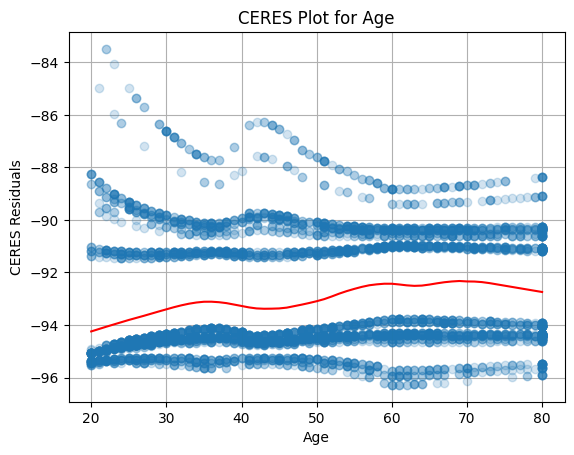

In [53]:
from statsmodels.graphics.regressionplots import add_lowess

fig = result.plot_ceres_residuals("age")
ax = fig.get_axes()[0]
ax.lines[0].set_alpha(0.2)
add_lowess(ax)
ax.grid(True)
ax.set_xlabel("Age", fontsize=10)
ax.set_ylabel("CERES Residuals", fontsize=10)
ax.set_title("CERES Plot for Age")
plt.show()

Taken at face value, CERES plot suggests that smoking rates may rise slightly faster for people between the ages of 20 and 35, and again for people between the ages of 50 and 60, with a period of minimal increase between these age intervals. This would contradict the perfectly linear model for age (on the log odds scale) that we have specified in our model. These plotting techniques can be useful at identifying possible opportunities for future analysis with additional data, but do not identify features that can be claimed with high confidence using the present data.

---

**Next:** [Multilevel Models: Introduction](../03_fitting_models_to_dependent_data/01_multilevel_models--introduction.md)